In [1]:

## Understanding Tensors in PyTorch
import torch

# create 2x2 tensor
tensor = torch.tensor([[1, 2], [3, 4]], dtype=torch.int8)
print(tensor)

tensor([[1, 2],
        [3, 4]], dtype=torch.int8)


In [2]:
# adding two tensors

t1 = torch.tensor([[1, 2], [3, 4]], dtype=torch.int8)
t2 = torch.tensor([[5, 6], [7, 8]], dtype=torch.int8)
result = t1 + t2
print(result)

tensor([[ 6,  8],
        [10, 12]], dtype=torch.int8)


In [3]:
# reshaping tensors

tensor = torch.tensor([[1, 2], [3, 4]], dtype=torch.int8)
reshaped_tensor = tensor.view(1, 4)
print(reshaped_tensor)

tensor([[1, 2, 3, 4]], dtype=torch.int8)


### Defining a simple neural network in PyTorch

In [4]:
from torch import nn
import time


class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(2,3) #
        self.output = nn.Linear(3,1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x



### Training the model with a simple dataset

In [5]:
model = SimpleNN()
inputs = torch.tensor([[0.5, 0.2], [0.9, 0.7]], dtype=torch.float32)
labels = torch.tensor([[1], [0]], dtype=torch.float32)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

n_epochs = 10

for epoch in range(n_epochs):
    time.sleep(0.3)  # Simulate some delay for demonstration purposes
    optimizer.zero_grad()
    output = model(inputs)
    loss = loss_fn(output, labels)
    loss.backward()
    optimizer.step()
    loss_score = round(loss.item(), 4)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss_score}', end='\r')

### Pre-Trained models in PyTorch

In [6]:
from PIL import Image
import torchvision
import requests

# set up default weights
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
# download pre-trained model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)

model.eval()

online_img_url = 'https://www.alleycat.org/wp-content/uploads/2019/03/FELV-cat.jpg'
image = Image.open(requests.get(online_img_url, stream=True).raw)

# image = Image.open(online_img_url)

transform = torchvision.transforms.Compose(
    transforms=[torchvision.transforms.ToTensor()],
)
image_tensor = transform(image).unsqueeze(0) # what is this ?
prediction = model(image_tensor)

In [7]:
boxes, scores, classes = prediction[0].values()
print(f'boxes: {boxes}')
print(f'scores: {scores}')
print(f'classes: {classes}')

boxes: tensor([[  7.7290,   9.7243, 454.0431, 459.9845]], grad_fn=<StackBackward0>)
scores: tensor([17])
classes: tensor([0.9787], grad_fn=<IndexBackward0>)


### Visualizing the predictions

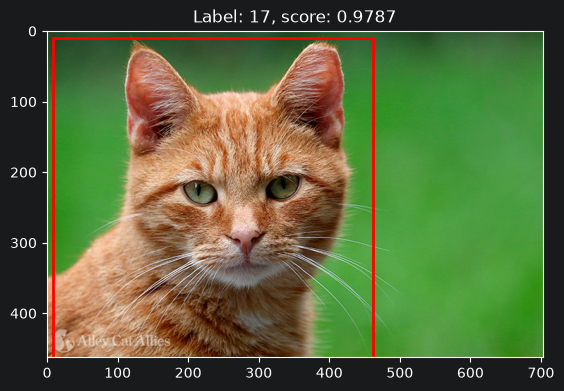

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1)
ax.imshow(image)
for box in prediction[0]['boxes']:
    x,y, w, h = box.detach().cpu().numpy()
    rect = patches.Rectangle(
        (x,y), w, h, linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

label = f'{scores[0].item()}'
score = round(classes[0].item(), 4)

plt.title(f'Label: {label}, score: {score}')
plt.show()